In [1]:
import os
print(os.getcwd())

C:\Users\ANUSHA\intership


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
iris_data = load_iris()

iris_df = pd.DataFrame(
    iris_data.data,
    columns=iris_data.feature_names
)

iris_df["Species"] = [iris_data.target_names[i] for i in iris_data.target]

In [3]:
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
iris_df.shape

(150, 5)

In [5]:
iris_df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
Species               object
dtype: object

In [6]:
iris_df.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64

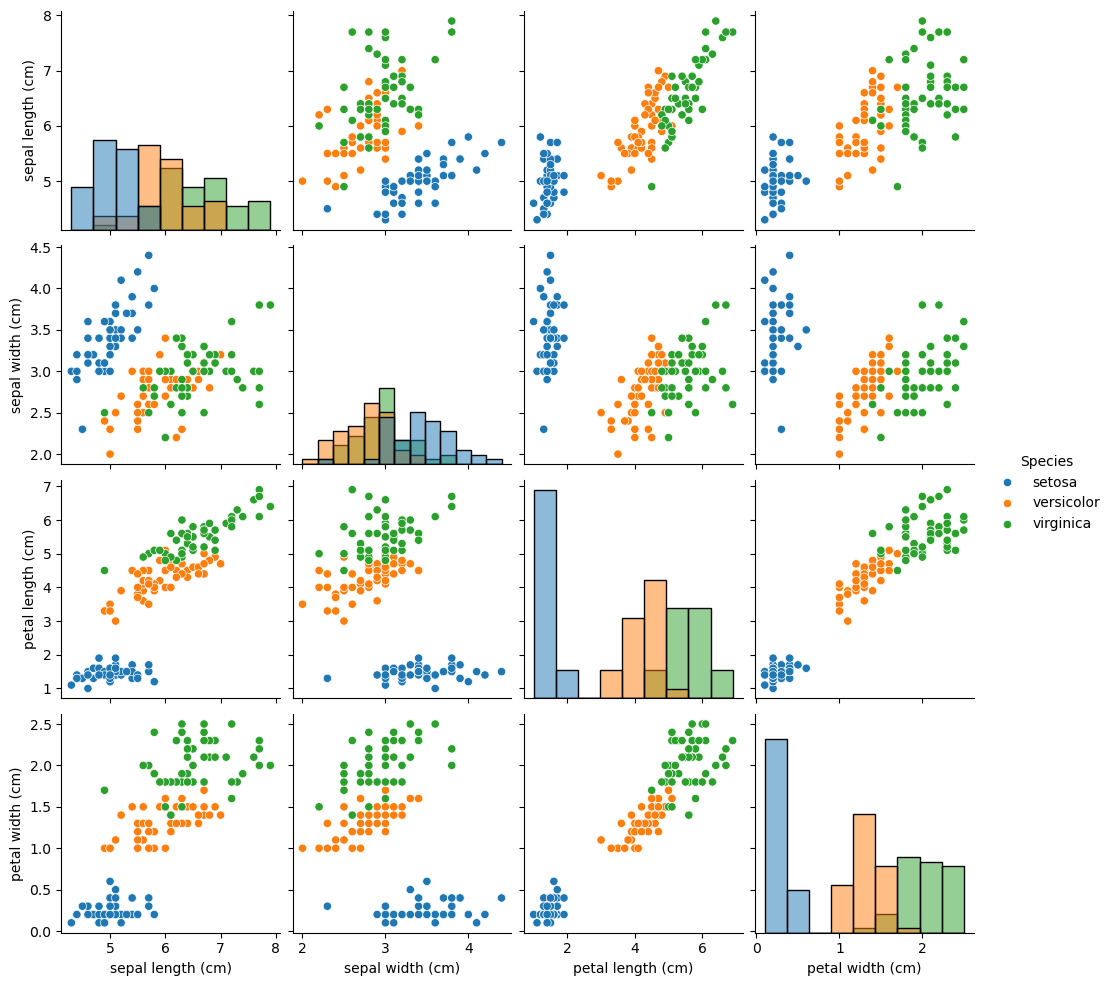

In [7]:
sns.pairplot(iris_df, hue="Species", diag_kind="hist")
plt.show()

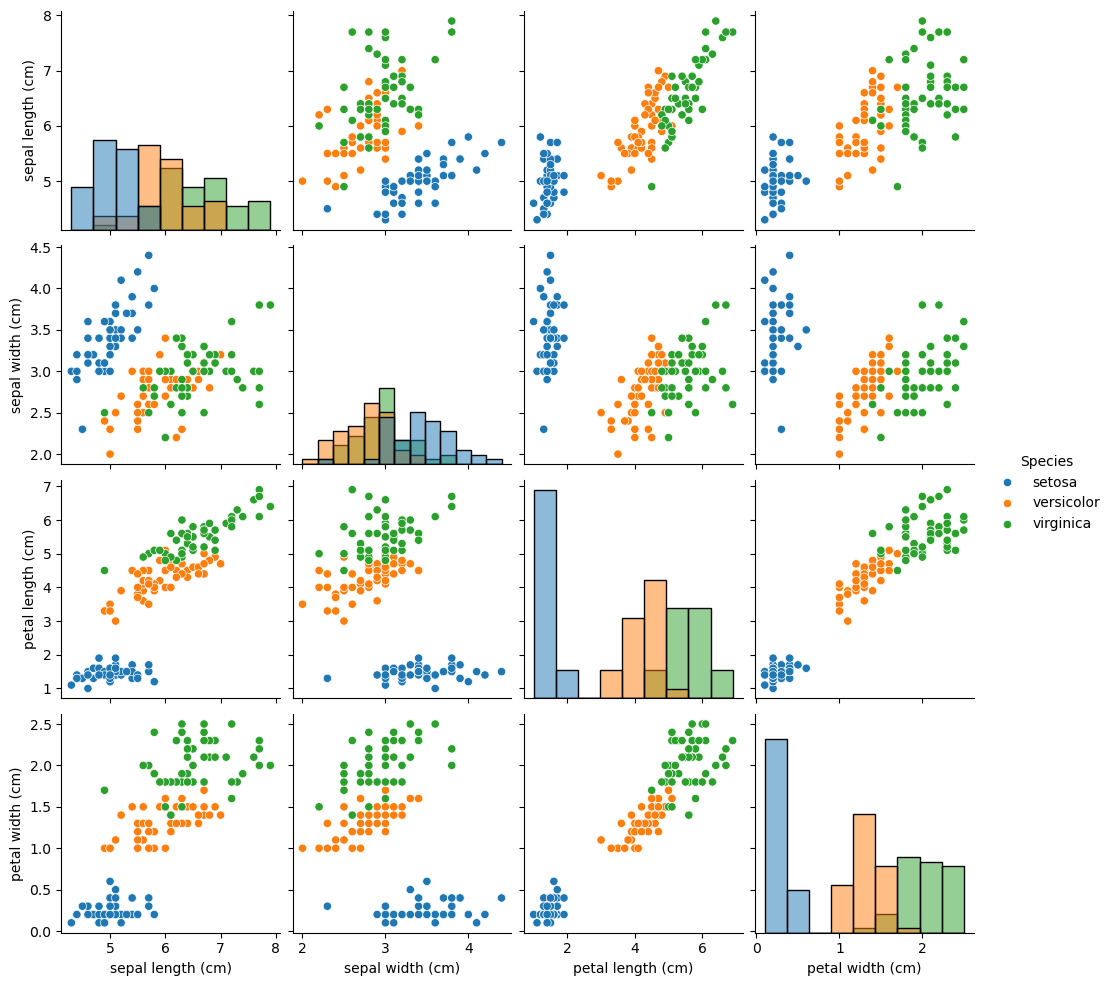

In [8]:
sns.pairplot(iris_df, hue="Species", diag_kind="hist")
plt.show()

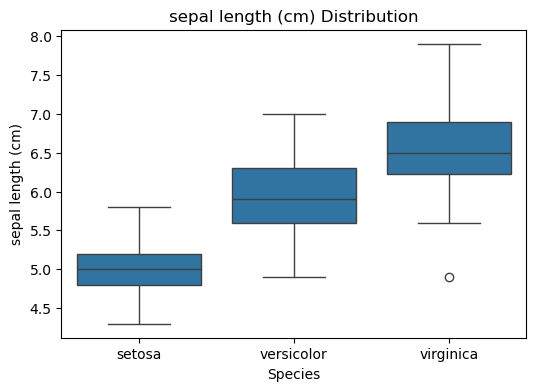

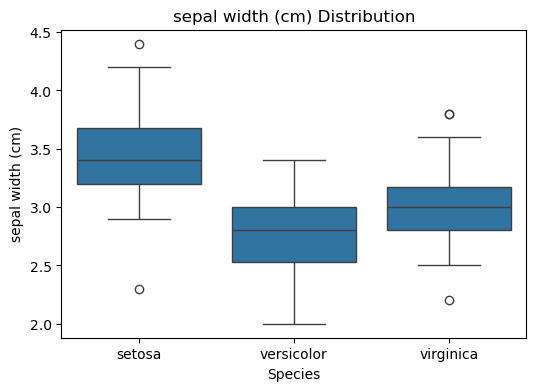

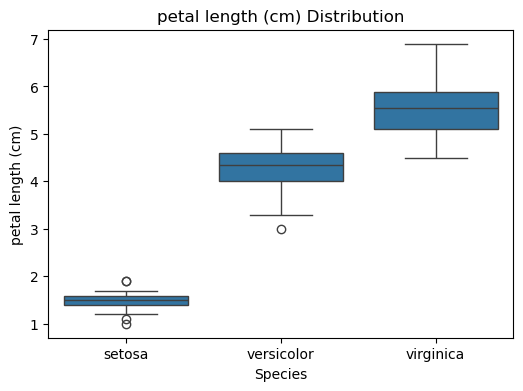

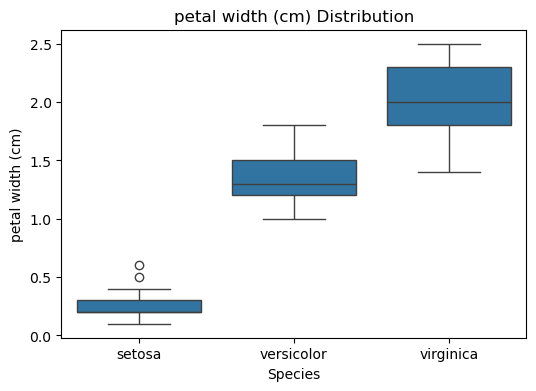

In [9]:
features = iris_df.columns[:-1]

for feature in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=iris_df, x="Species", y=feature)
    plt.title(f"{feature} Distribution")
    plt.show()

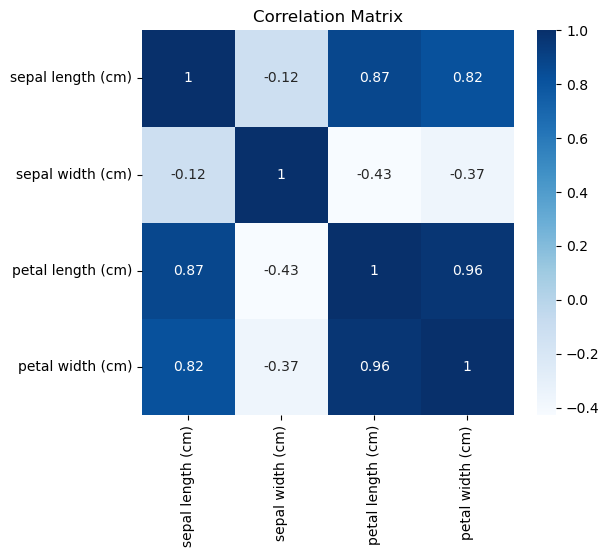

In [10]:
correlation = iris_df.iloc[:, :-1].corr()

plt.figure(figsize=(6,5))
sns.heatmap(correlation, annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

In [11]:
X = iris_df.iloc[:, :-1]
y = iris_df["Species"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [13]:
log_model = LogisticRegression(max_iter=200)

log_model.fit(X_train, y_train)

log_predictions = log_model.predict(X_test)

In [14]:
print("Accuracy:", accuracy_score(y_test, log_predictions))
print(confusion_matrix(y_test, log_predictions))
print(classification_report(y_test, log_predictions))

Accuracy: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [15]:
knn_model = KNeighborsClassifier(n_neighbors=3)

knn_model.fit(X_train, y_train)

knn_predictions = knn_model.predict(X_test)

In [16]:
print("Accuracy:", accuracy_score(y_test, knn_predictions))
print(confusion_matrix(y_test, knn_predictions))
print(classification_report(y_test, knn_predictions))

Accuracy: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [17]:
comparison = pd.DataFrame({
    "Algorithm": ["Logistic Regression", "KNN"],
    "Accuracy Score": [
        accuracy_score(y_test, log_predictions),
        accuracy_score(y_test, knn_predictions)
    ]
})

comparison

,Algorithm,Accuracy Score
0,Logistic Regression,1.0
1,KNN,1.0
